<a href="https://colab.research.google.com/github/BenjaminJones-lccc/Machine-learning-week-9/blob/main/Week_9_(Gym_by_openAI)v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gym by OpenAI
Gym is a toolkit for developing and comparing reinforcement learning algorithms. <br>
It makes no assumptions about the structure of your agent, and is compatible with any numerical computation library, such as TensorFlow or Theano. <br>

The gym library is a collection of test problems — environments — that you can use to work out your reinforcement learning algorithms. <br>
These environments have a shared interface, allowing you to write general algorithms.

# Installation
To get started, you’ll need to have Python 3.5+ installed. Simply install gym using pip: <br>
Please take note, this step works well for Mac and Linux. <br>
If you are using Windows, you will need to do some workaround, using this link: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30 <br>

Please remember, you will need to install the following libraries: <br>
1. pystan
2. swig
3. Box2D

You may need to install other libraries depending on the environments that you are using.

## The environments
We will be looking at a few environments:
1. CartPole-v1
2. MountainCar-v0
3. BipedalWalker-v3
4. LunarLander-v2
5. CarRacing-v0
6. Pendulum-v0
7. Acrobot-v1
8. Taxi-v3
9. Copy-v0

We will look at the problems posed. <br>
As this is an introductory course, we will not go in-depth of the solutions. <br>
You are encouraged to find the answers online by yourself.

In [1]:
!pip install gymnasium pygame Box2D

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 22.7 MB/s eta 0:00:00


In [3]:
!pip install gym[classic_control]

  Using cached pygame-2.1.0.tar.gz (5.8 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [4]:
!pip install Box2D

## 1. Cart Pole
A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. <br>
The system is controlled by applying a force of +1 or -1 to the cart. <br>
The pendulum starts upright, and the goal is to prevent it from falling over. <br>
A reward of +1 is provided for every timestep that the pole remains upright. <br>
The episode ends when the pole is more than 15 degrees from vertical or the cart moves more than 2.4 units from the center.

In [5]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

In [6]:
def render_notebook(env, img=None):
    frame = env.render()

    # Create the plot on the first frame
    if img is None:
        plt.figure(figsize=(6, 4))
        img = plt.imshow(frame)
        plt.axis('off')
    # Update the existing plot for subsequent frames
    else:
        img.set_data(frame)

    display.display(plt.gcf())
    display.clear_output(wait=True)

    return img

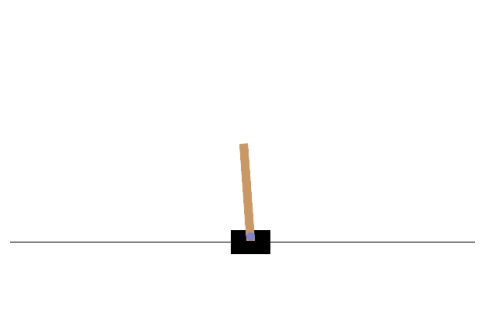

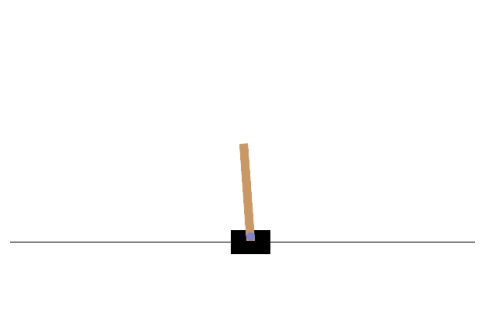

In [7]:


# 1. Initialize the environment first, with the correct render mode
env = gym.make('CartPole-v1', render_mode="rgb_array")
env.reset()

# 2. Now set up the plot using the initialized environment
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(env.render())
ax.axis('off')

# 3. Run the loop with the display logic
for _ in range(200):
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())

    img.set_data(env.render())

    display.clear_output(wait=True)
    display.display(fig)

    if terminated or truncated:
        env.reset()

env.close()

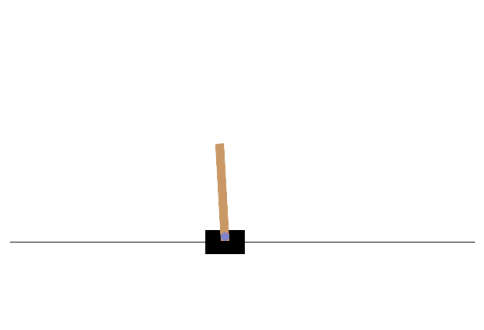

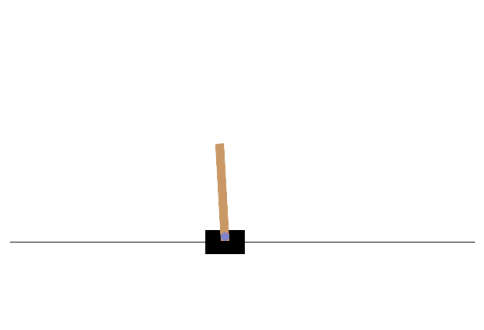

In [8]:
# 1. Initialize the environment first, with the correct render mode
env = gym.make('CartPole-v1', render_mode="rgb_array")
env.reset()

# 2. Now set up the plot using the initialized environment
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(env.render())
ax.axis('off')

# 3. Run the loop with the display logic
for _ in range(200):
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())

    img.set_data(env.render())

    display.clear_output(wait=True)
    display.display(fig)

    if terminated or truncated:
        env.reset()

env.close()

## 2. Mountain Car
A car is on a one-dimensional track, positioned between two "mountains". <br>
The goal is to drive up the mountain on the right; however, the car's engine is not strong enough to scale the mountain in a single pass. <br>
Therefore, the only way to succeed is to drive back and forth to build up momentum.

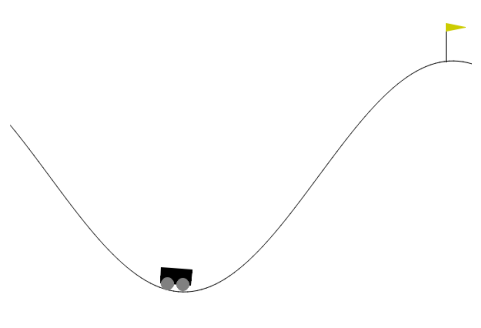

In [9]:


env = gym.make("MountainCar-v0", render_mode="rgb_array")
env.reset()

img = None
for _ in range(50):
    env.step(env.action_space.sample())
    # Update the display and keep track of the image object
    img = render_notebook(env, img)

env.close()

## 3. Bipedal
Reward is given for moving forward, total 300+ points up to the far end. <br>
If the robot falls, it gets -100. <br>
Applying motor torque costs a small amount of points, more optimal agent will get better score. <br>
State consists of hull angle speed, angular velocity, horizontal speed, vertical speed, position of joints and joints angular speed, legs contact with ground, and 10 lidar rangefinder measurements. <br>
There's no coordinates in the state vector.

In [11]:
import gym
env = gym.make('BipedalWalker-v3')
env.reset()
for _ in range(1000):
    env.render()
    env.step(env.action_space.sample()) # take a random action
env.close()

AttributeError: module 'numpy' has no attribute 'bool8'

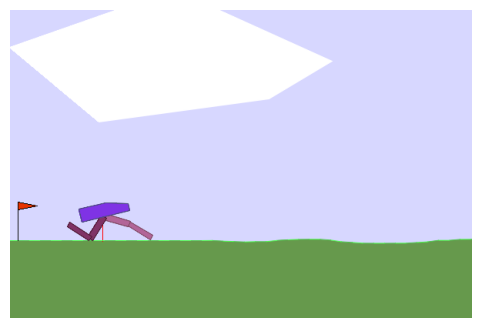

In [12]:
import gymnasium as gym

# 1. Initialize with render_mode="rgb_array"
env = gym.make('BipedalWalker-v3', render_mode="rgb_array")
env.reset()

img = None
for _ in range(1000):
    # 2. Call our wrapper to handle the rendering and display
    img = render_notebook(env, img)

    # 3. Take the step
    # Note: step() returns 5 values in Gymnasium (obs, reward, terminated, truncated, info)
    env.step(env.action_space.sample())

env.close()

In [17]:
# can we introduce a solution here?
"To solve the rendering issue in a notebook environment, you can use the following approach:
"using Ipython.display and matplotlib to capture the array and update
"a sngle plot in the notebook."

SyntaxError: unterminated string literal (detected at line 2) (2503648523.py, line 2)

## 4. Lunar Lander
Landing pad is always at coordinates (0,0). <br>
Coordinates are the first two numbers in the state vector. <br>
Reward for moving from the top of the screen to landing pad and zero speed is about 100..140 points. <br>
If the lander moves away from the landing pad it loses reward back. <br>
The episode finishes if the lander crashes or comes to rest, receiving additional -100 or +100 points. <br>
Each leg ground contact is +10. The Firing main engine is -0.3 points each frame. Solved is 200 points. <br>
Landing outside the landing pad is possible. <br>
Fuel is infinite, so an agent can learn to fly and then land on its first attempt. <br>
Four discrete actions are available: do nothing, fire left orientation engine, fire main engine, fire right orientation engine.

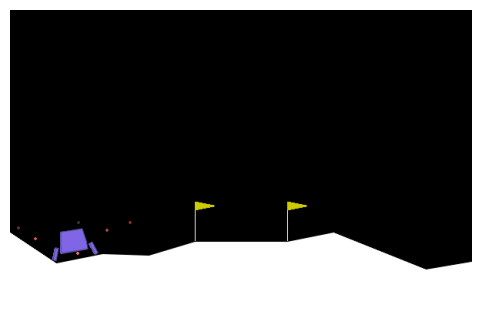

In [14]:
import gymnasium as gym
env = gym.make('LunarLander-v3', render_mode="rgb_array")
img = None
env.reset()
for _ in range(500):
    #env.render()
    img = render_notebook(env, img)
    env.step(env.action_space.sample()) # take a random action
env.close()

In [ ]:
# can we introduce a solution here?
# Again, using IPython.display and matplotlib to capture the array
# would fix the problem.

## 5. Car Racing
Easiest continuous control task to learn from pixels, a top-down racing environment.<br>
Discreet control is reasonable in this environment as well, on/off discretisation is fine. <br>
State consists of 96x96 pixels. <br>
Reward is -0.1 every frame and +1000/N for every track tile visited, where N is the total number of tiles in track. <br>
For example, if you have finished in 732 frames, your reward is 1000 - 0.1*732 = 926.8 points. <br>
Episode finishes when all tiles are visited. Some indicators shown at the bottom of the window and the state RGB buffer. <br>
From left to right: true speed, four ABS sensors, steering wheel position, gyroscope.

KeyboardInterrupt: 

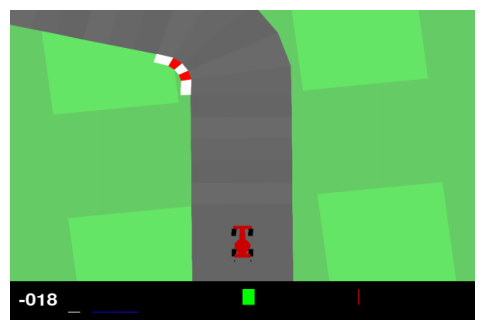

In [15]:
import gymnasium as gym
env = gym.make('CarRacing-v3', render_mode="rgb_array")
env.reset()

# Set up the initial plot
plt.figure(figsize=(6, 6))
img = plt.imshow(env.render())
plt.axis('off')

for _ in range(2000):
    img = render_notebook(env, img)
    env.step(env.action_space.sample()) # take a random action
env.close()

In [ ]:
# can we introduce a solution here?
# This time, we need to use img.set_data() to
# update the pixels and refresh the notebook's cell

## 6. Pendulum
The inverted pendulum swing-up problem is a classic problem in the control literature. <br>
In this version of the problem, the pendulum starts in a random position, and the goal is to swing it up so it stays upright.

KeyboardInterrupt: 

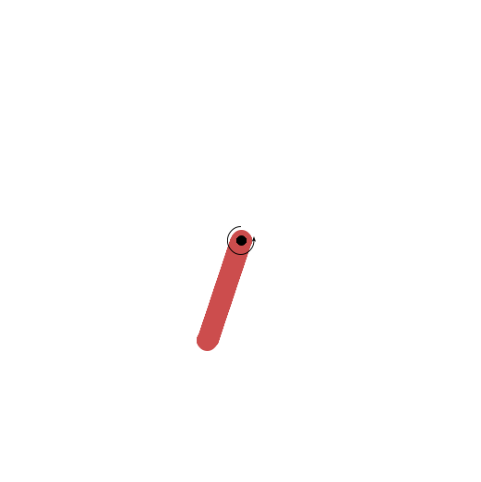

In [20]:
import gymnasium as gym
env = gym.make('Pendulum-v1', render_mode="rgb_array")
env.reset()

# Set up the initial plot
plt.figure(figsize=(6, 6))
img = plt.imshow(env.render())
plt.axis('off')

for _ in range(5100):
    img = render_notebook(env, img)
    env.step(env.action_space.sample()) # take a random action
env.close()

In [ ]:
# can we introduce a solution here?
#We neeed to replace the for loop with a version
# that uses Ipython.display to update the exisiting plot

## 7. Acrobot
The acrobot system includes two joints and two links, where the joint between the two links is actuated. <br>
Initially, the links are hanging downwards, and the goal is to swing the end of the lower link up to a given height.

In [19]:
import gymnasium as gym
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env.reset()
for _ in range(5100):
    img = plt.imshow(env.render())
    env.step(env.action_space.sample()) # take a random action
env.close()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d2285d4ccc0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d2285f1e200> (for post_execute):


KeyboardInterrupt: 

In [ ]:
# can we introduce a solution here?
#must use IPython.display

## 8. Taxi
This task was introduced  to illustrate some issues in hierarchical reinforcement learning. <br>
There are 4 locations (labeled by different letters) and your job is to pick up the passenger at one location and drop him off in another. <br>
You receive +20 points for a successful drop-off, and lose 1 point for every timestep it takes. <br>
There is also a 10 point penalty for illegal pick-up and drop-off actions.

KeyboardInterrupt: 

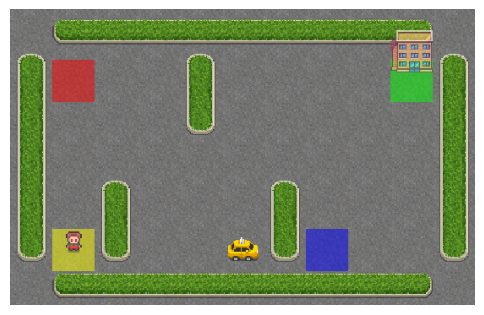

In [18]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

env = gym.make('Taxi-v3', render_mode="rgb_array")
env.reset()

# Capture the figure object so we can explicitly display it
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(env.render())
ax.axis('off')

for _ in range(200):
    # Unpack the step results to check if the episode is done
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())

    # Update the image data
    img.set_data(env.render())

    # Clear the old frame and force the new frame to display
    display.clear_output(wait=True)
    display.display(fig)

    # Reset the environment if the taxi finishes or runs out of time
    if terminated or truncated:
        env.reset()

env.close()

In [ ]:
# can we introduce a solution here?
#Before the loop starts, maybe ensuring that the first frame is rendered?

## 9. Copy
This task involves copying the symbols from the input tape to the output tape. <br>
Although simple, the model still has to learn the correspondence between input and output symbols. <br>
It also has to learn about executing the move right action on the input tape.

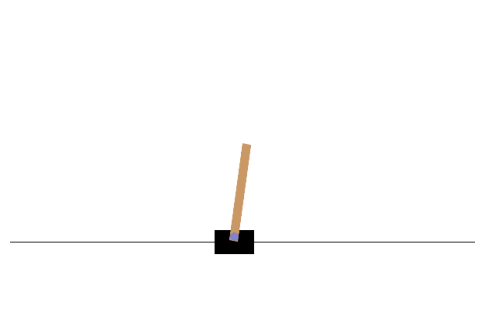

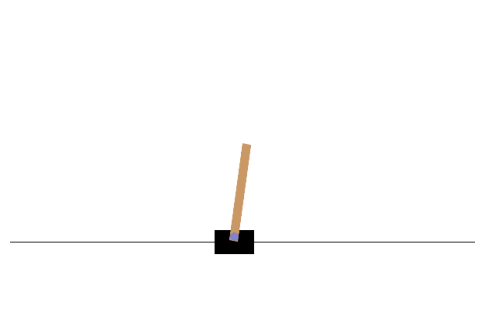

In [22]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

# Copy-v0 is deprecated. Using CartPole-v1 instead.
env = gym.make('CartPole-v1', render_mode="rgb_array")
env.reset()

fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(env.render())
ax.axis('off')

for _ in range(50):
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())

    img.set_data(env.render())

    display.clear_output(wait=True)
    display.display(fig)

    if terminated or truncated:
        env.reset()

env.close()

In [ ]:
# can we introduce a solution here?
#